# 02 — Debug Model

End-to-end sanity check of the training pipeline:
1. Load `configs/default.yaml`
2. Build dataset + transforms from `training/`
3. Create a DataLoader and inspect one batch
4. Draw ground-truth boxes
5. Run one forward pass through the model
6. Compute and print all losses

In [1]:
import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from omegaconf import OmegaConf

# Resolve project root whether notebook is run from repo root or notebooks/
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

print(f"Project root  : {ROOT}")
print(f"PyTorch       : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Project root  : /home/gutenbye/Documents/UIT/Semester_2/NMAI/priv_proj
PyTorch       : 2.2.2+cpu
CUDA available: False


## 1. Load config

In [2]:
cfg = OmegaConf.load(ROOT / "configs" / "default.yaml")
print(OmegaConf.to_yaml(cfg))

model:
  backbone:
    name: resnet50
    pretrained: true
    freeze_at: 1
    out_indices:
    - 1
    - 2
    - 3
  neck:
    out_channels: 256
    num_levels: 4
  transformer:
    d_model: 256
    nhead: 8
    num_encoder_layers: 6
    num_decoder_layers: 6
    dim_feedforward: 2048
    dropout: 0.1
  num_classes: 356
  num_queries: 300
  aux_loss: true
data:
  ann_file: data/raw/coco_dataset/train/annotations.json
  img_dir: data/raw/coco_dataset/train/images
  max_size: 800
  num_workers: 4
  batch_size: 2
  val_split: 0.2
  seed: 42
training:
  max_epochs: 50
  base_lr: 0.0001
  backbone_lr: 1.0e-05
  weight_decay: 0.0001
  grad_clip: 0.1
  lr_milestones:
  - 40
  lr_gamma: 0.1
  focal_alpha: 0.25
  focal_gamma: 2.0
  matcher:
    cost_class: 2.0
    cost_bbox: 5.0
    cost_giou: 2.0
  loss_weights:
    loss_ce: 2.0
    loss_bbox: 5.0
    loss_giou: 2.0
  checkpoint_dir: models/checkpoints
  log_every_n_steps: 10
inference:
  threshold: 0.3
  nms_threshold: 0.5
  top_k: 300
  de

## 2. Build dataset and transforms

In [3]:
from training.dataset import COCODetectionDataset, collate_fn
from training.transforms import build_val_transforms

# Use val transforms (deterministic — no random augmentation)
transforms = build_val_transforms(max_size=cfg.data.max_size)

dataset = COCODetectionDataset(
    ann_file=str(ROOT / cfg.data.ann_file),
    img_dir=str(ROOT / cfg.data.img_dir),
    transforms=transforms,
)

print(f"Dataset size : {len(dataset)}")
print(f"Num classes  : {len(dataset.cat_id_to_idx)}")
print(f"First 5 cat_id -> idx: {dict(list(dataset.cat_id_to_idx.items())[:5])}")

/home/gutenbye/Documents/UIT/Semester_2/NMAI/priv_proj/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Dataset size : 248
Num classes  : 356
First 5 cat_id -> idx: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


In [4]:
import numpy as np
print(np.__version__)

1.26.4


## 3. Create DataLoader and load one batch

In [5]:
from torch.utils.data import DataLoader, Subset
import numpy as np

# Small subset so the notebook runs quickly regardless of dataset size
N_SAMPLES = min(4, len(dataset))
subset = Subset(dataset, list(range(N_SAMPLES)))

loader = DataLoader(
    subset,
    batch_size=2,
    shuffle=False,
    num_workers=0,       # keep deterministic and IDE-friendly
    collate_fn=collate_fn,
)

batch = next(iter(loader))

print("Batch keys      :", list(batch.keys()))
print(f"images shape    : {batch['images'].shape}     (B, 3, H_max, W_max)")
print(f"image_mask shape: {batch['image_mask'].shape}  (B, H_max, W_max)  True=padding")
print(f"num targets     : {len(batch['targets'])}")
print(f"sizes           : {batch['sizes'].tolist()}")
print()
for i, t in enumerate(batch["targets"]):
    n = len(t["boxes"])
    print(f"  sample {i}: {n} boxes | labels[:8] = {t['labels'].tolist()[:8]}")

Batch keys      : ['images', 'image_mask', 'targets', 'image_ids', 'orig_sizes', 'sizes']
images shape    : torch.Size([2, 3, 608, 800])     (B, 3, H_max, W_max)
image_mask shape: torch.Size([2, 608, 800])  (B, H_max, W_max)  True=padding
num targets     : 2
sizes           : [[608, 800], [608, 800]]

  sample 0: 99 boxes | labels[:8] = [206, 206, 142, 222, 222, 325, 325, 182]
  sample 1: 76 boxes | labels[:8] = [272, 272, 219, 219, 151, 151, 355, 165]


## 4. Visualise one batch — draw ground-truth boxes

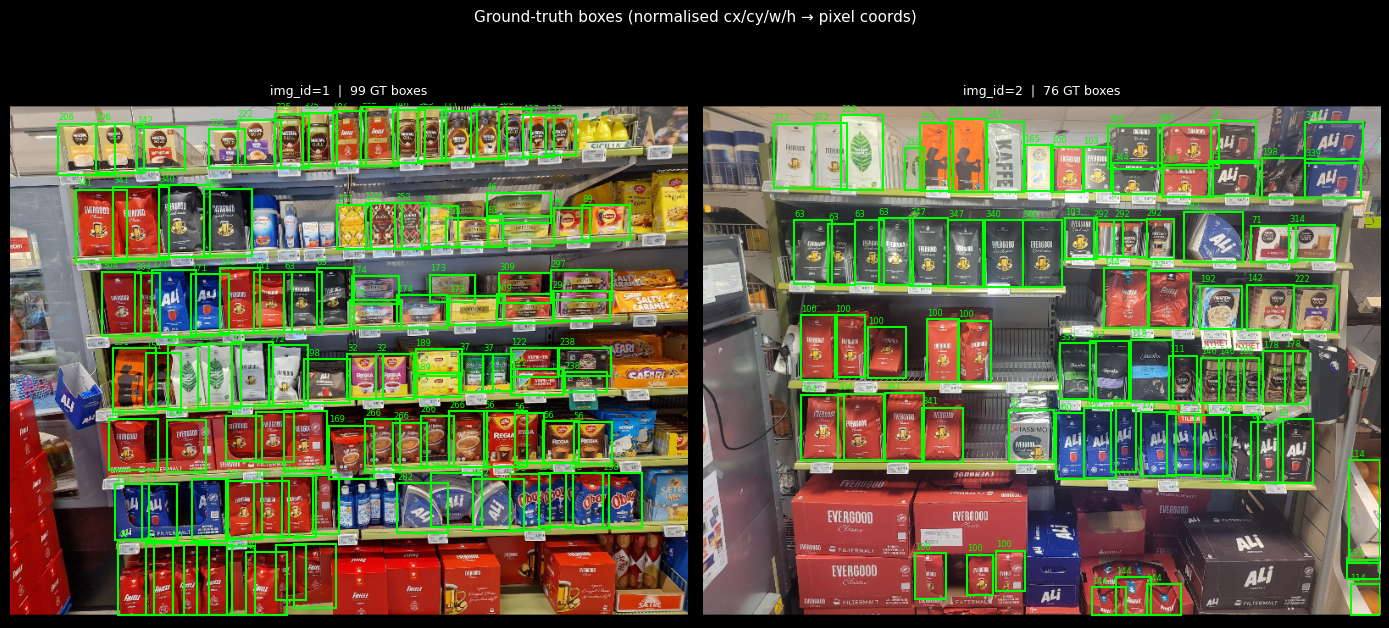

In [6]:
# ImageNet stats used in transforms.py
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def denormalize(img_tensor: torch.Tensor) -> np.ndarray:
    """Undo ImageNet normalisation; return HxWx3 float32 in [0, 1]."""
    return (img_tensor * _STD + _MEAN).clamp(0.0, 1.0).permute(1, 2, 0).numpy()


def draw_gt_boxes(
    ax: plt.Axes,
    img_np: np.ndarray,
    boxes_cxcywh: torch.Tensor,
    labels: torch.Tensor,
    title: str = "",
) -> None:
    """Plot image with normalised cx/cy/w/h ground-truth boxes."""
    H, W = img_np.shape[:2]
    ax.imshow(img_np)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    for box, lbl in zip(boxes_cxcywh, labels):
        cx, cy, bw, bh = box.tolist()
        x1 = (cx - bw / 2) * W
        y1 = (cy - bh / 2) * H
        rect = patches.Rectangle(
            (x1, y1), bw * W, bh * H,
            linewidth=1.5, edgecolor="lime", facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 2, str(lbl.item()), fontsize=6,
                color="lime", va="bottom", clip_on=True)


B = batch["images"].shape[0]
fig, axes = plt.subplots(1, B, figsize=(7 * B, 7))
if B == 1:
    axes = [axes]

for i in range(B):
    img_np = denormalize(batch["images"][i])
    # Blank out the padded region so it does not mislead
    h, w = batch["sizes"][i].tolist()
    img_np[h:, :] = 0.0
    img_np[:, w:] = 0.0

    boxes  = batch["targets"][i]["boxes"]
    labels = batch["targets"][i]["labels"]
    title  = f"img_id={batch['image_ids'][i]}  |  {len(boxes)} GT boxes"
    draw_gt_boxes(axes[i], img_np, boxes, labels, title=title)

plt.suptitle("Ground-truth boxes (normalised cx/cy/w/h → pixel coords)", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Build model

In [7]:
from models.groundingdino.neck import build_neck, FPN
from models.groundingdino.backbone import build_backbone

bb = build_backbone(cfg.model.backbone)
print("out_channels:", bb.out_channels)
print("num_levels from config:", cfg.model.neck.num_levels)
build_neck(cfg.model.neck, bb.out_channels)
bb = build_backbone(cfg.model.backbone)
print("out_channels:", bb.out_channels)
print("len(out_channels):", len(bb.out_channels))
print("num_levels:", cfg.model.neck.num_levels)

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2+cpu
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


out_channels: [256, 512, 1024]
num_levels from config: 4
out_channels: [256, 512, 1024]
len(out_channels): 3
num_levels: 4


In [8]:
print(OmegaConf.to_yaml(cfg.model))

backbone:
  name: resnet50
  pretrained: true
  freeze_at: 1
  out_indices:
  - 1
  - 2
  - 3
neck:
  out_channels: 256
  num_levels: 4
transformer:
  d_model: 256
  nhead: 8
  num_encoder_layers: 6
  num_decoder_layers: 6
  dim_feedforward: 2048
  dropout: 0.1
num_classes: 356
num_queries: 300
aux_loss: true



In [9]:
from models.groundingdino.model import build_model

model = build_model(cfg)
model.eval()

total      = sum(p.numel() for p in model.parameters())
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
backbone_p = sum(p.numel() for p in model.backbone.parameters())

print(f"Backbone       : {cfg.model.backbone.name}")
print(f"Num classes    : {cfg.model.num_classes}")
print(f"Num queries    : {cfg.model.num_queries}")
print(f"d_model        : {cfg.model.transformer.d_model}")
print()
print(f"Total params   : {total:>12,}")
print(f"Trainable      : {trainable:>12,}")
print(f"Backbone params: {backbone_p:>12,}")

Backbone       : resnet50
Num classes    : 356
Num queries    : 300
d_model        : 256

Total params   :   30,491,744
Trainable      :   30,482,208
Backbone params:    8,543,296


## 6. One forward pass

In [10]:
import torch.nn.functional as F

images     = batch["images"]
image_mask = batch["image_mask"]

# Downscale to 320x320 for CPU debug run — avoids 100GB+ attention matrix
images_small = F.interpolate(images, size=(320, 320))
mask_small   = F.interpolate(image_mask[:, None].float(), size=(320, 320)).squeeze(1).bool()

with torch.no_grad():
    outputs = model(images_small, mask_small)

print("Forward pass outputs")
print(f"  pred_logits : {outputs['pred_logits'].shape}   (B, Q, num_classes)")
print(f"  pred_boxes  : {outputs['pred_boxes'].shape}    (B, Q, 4)  cx/cy/w/h in [0,1]")
print(f"  aux_outputs : {len(outputs.get('aux_outputs', []))} intermediate decoder layer(s)")
print()

boxes = outputs["pred_boxes"]
print("pred_boxes stats:")
print(f"  min  = {boxes.min().item():.4f}")
print(f"  max  = {boxes.max().item():.4f}")
print(f"  mean = {boxes.mean().item():.4f}")

logits = outputs["pred_logits"]
top_scores, top_classes = logits.sigmoid().max(-1)   # (B, Q)
print()
print("Top-5 detection scores (sigmoid) per image:")
for i in range(images.shape[0]):
    vals, idxs = top_scores[i].topk(5)
    entries = [(f"{v:.3f}", f"cls={c}") for v, c in
               zip(vals.tolist(), top_classes[i][idxs].tolist())]
    print(f"  img {i}: {entries}")

Forward pass outputs
  pred_logits : torch.Size([2, 300, 356])   (B, Q, num_classes)
  pred_boxes  : torch.Size([2, 300, 4])    (B, Q, 4)  cx/cy/w/h in [0,1]
  aux_outputs : 5 intermediate decoder layer(s)

pred_boxes stats:
  min  = nan
  max  = nan
  mean = nan

Top-5 detection scores (sigmoid) per image:
  img 0: [('nan', 'cls=0'), ('nan', 'cls=0'), ('nan', 'cls=0'), ('nan', 'cls=0'), ('nan', 'cls=0')]
  img 1: [('nan', 'cls=0'), ('nan', 'cls=0'), ('nan', 'cls=0'), ('nan', 'cls=0'), ('nan', 'cls=0')]


## 7. Compute losses

In [11]:
from training.losses import SetCriterion
from models.groundingdino.matcher import HungarianMatcher

# Mirror exactly what DetectionLightningModule does in training/trainer.py
matcher = HungarianMatcher(
    cost_class=cfg.training.matcher.cost_class,
    cost_bbox=cfg.training.matcher.cost_bbox,
    cost_giou=cfg.training.matcher.cost_giou,
)

lw = cfg.training.loss_weights
weight_dict = {
    "loss_ce":   float(lw.loss_ce),
    "loss_bbox": float(lw.loss_bbox),
    "loss_giou": float(lw.loss_giou),
}
for i in range(cfg.model.transformer.num_decoder_layers - 1):
    weight_dict[f"loss_ce_{i}"]   = float(lw.loss_ce)
    weight_dict[f"loss_bbox_{i}"] = float(lw.loss_bbox)
    weight_dict[f"loss_giou_{i}"] = float(lw.loss_giou)

criterion = SetCriterion(
    num_classes=cfg.model.num_classes,
    matcher=matcher,
    weight_dict=weight_dict,
    focal_alpha=float(cfg.training.get("focal_alpha", 0.25)),
    focal_gamma=float(cfg.training.get("focal_gamma", 2.0)),
)

targets = batch["targets"]

with torch.no_grad():
    losses = criterion(outputs, targets)

print("Losses (untrained model — values are expected to be large)")
print("-" * 50)
final_keys = ["loss_ce", "loss_bbox", "loss_giou"]
aux_keys   = sorted(k for k in losses if k not in final_keys and k != "loss_total")
for k in final_keys + aux_keys + ["loss_total"]:
    if k in losses:
        weight = weight_dict.get(k, 1.0)
        raw    = losses[k].item()
        print(f"  {k:<24s}  raw={raw:9.4f}   weight={weight}")
print("-" * 50)
print(f"  {'loss_total':<24s}  {losses['loss_total'].item():.4f}")

ValueError: matrix contains invalid numeric entries